<h1 style="text-align: center; font-weight: bold; font-size: 36px; ">Student Performance Prediction</h1>


### Objective

<p style="font-size: 20px;">The objective of this notebook is to predict student performance based on multiple factors such as study time, attendance, previous academic records, and demographic information. Using a dataset containing various features, we aim to build a model that accurately predicts student performance, helping educators and institutions identify students at risk and optimize resources for improved academic outcomes.</p>

# Table of Contents
- [Data Loading](#Data-Loading)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)
- [Data Visualization](#Data-Visualization)
- [Data Preprocessing](#Data-Preprocessing)
- [Train Test & Split](#Train-Test-And-Split)
- [Model Training](#Model-Training)
- [Model-Evaluation](#Model-Evaluation)
- [Conclusion](#Conclusion)


## Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/kaggle/input/student-performance-factors/StudentPerformanceFactors.csv')

## Exploratory Data Analysis

In [3]:
df.head(5)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.shape

(6607, 20)

In [5]:
df.shape

(6607, 20)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [7]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [8]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.nunique()

Hours_Studied                 41
Attendance                    41
Parental_Involvement           3
Access_to_Resources            3
Extracurricular_Activities     2
Sleep_Hours                    7
Previous_Scores               51
Motivation_Level               3
Internet_Access                2
Tutoring_Sessions              9
Family_Income                  3
Teacher_Quality                3
School_Type                    2
Peer_Influence                 3
Physical_Activity              7
Learning_Disabilities          2
Parental_Education_Level       3
Distance_from_Home             3
Gender                         2
Exam_Score                    45
dtype: int64

## Data Visualization

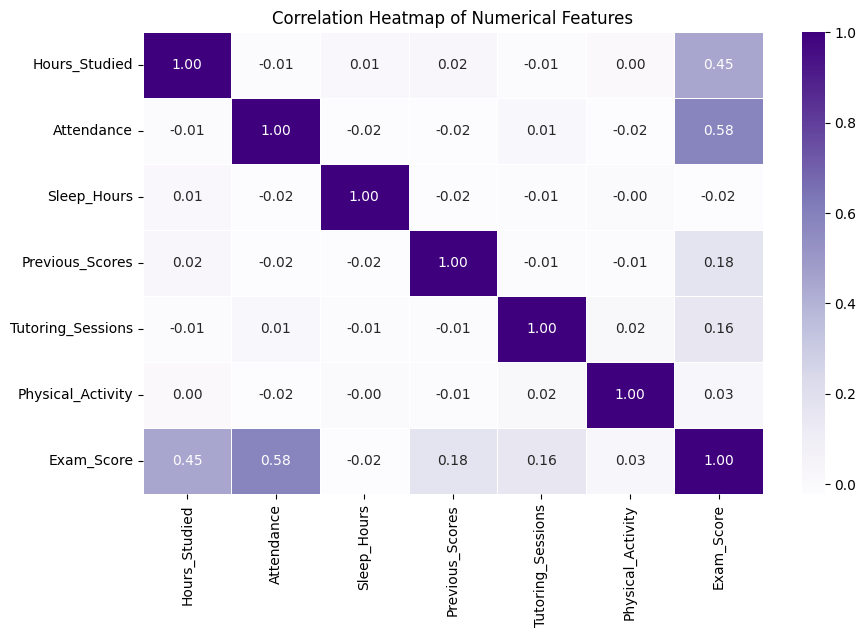

In [11]:
# Correlation Heatmap for numerical features

numerical_features = df[['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']]
correlation_matrix = numerical_features.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Purples', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [35]:
# Histogram for Exam Score

fig = px.histogram(
    data_frame=df,
    x='Exam_Score', 
    nbins=20, 
    marginal='box', 
    color_discrete_sequence=['#6c3483'], 
    text_auto=True,
    title='Distribution of Exam Scores'
)

fig.show()

In [13]:
# Histogram for Hours Studied

fig = px.histogram(
    data_frame=df,
    x='Hours_Studied', 
    nbins=25, 
    marginal='rug', 
    color_discrete_sequence=['#3498db'], 
    text_auto=True, 
    title='Distribution of Hours Studied'
)

fig.show()


In [14]:
#  Histogram for Attendance

fig = px.histogram(
    data_frame=df,
    x='Attendance', 
    nbins=30, 
    marginal='violin',  
    color='School_Type', 
    color_discrete_sequence=['#1f77b4', '#ff7f0e'], 
    text_auto=True,  
    title='Attendance Distribution by School Type' 
)

fig.show()


In [15]:
# Histogram for Motivation Level

fig = px.histogram(
    data_frame=df,
    x='Motivation_Level', 
    nbins=10,  
    marginal='box',  
    color_discrete_sequence=['#f39c12'],
    text_auto=True,  
    title='Motivation Level Distribution'
)

fig.show()


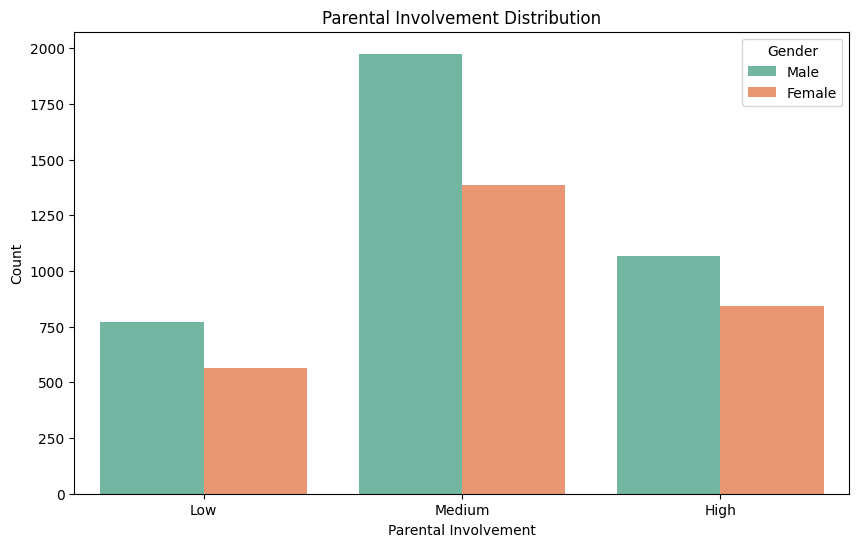

In [16]:
# Bar Plot for categorical features

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Parental_Involvement', hue='Gender', palette='Set2')
plt.title('Parental Involvement Distribution')
plt.xlabel('Parental Involvement')
plt.ylabel('Count')
plt.show()

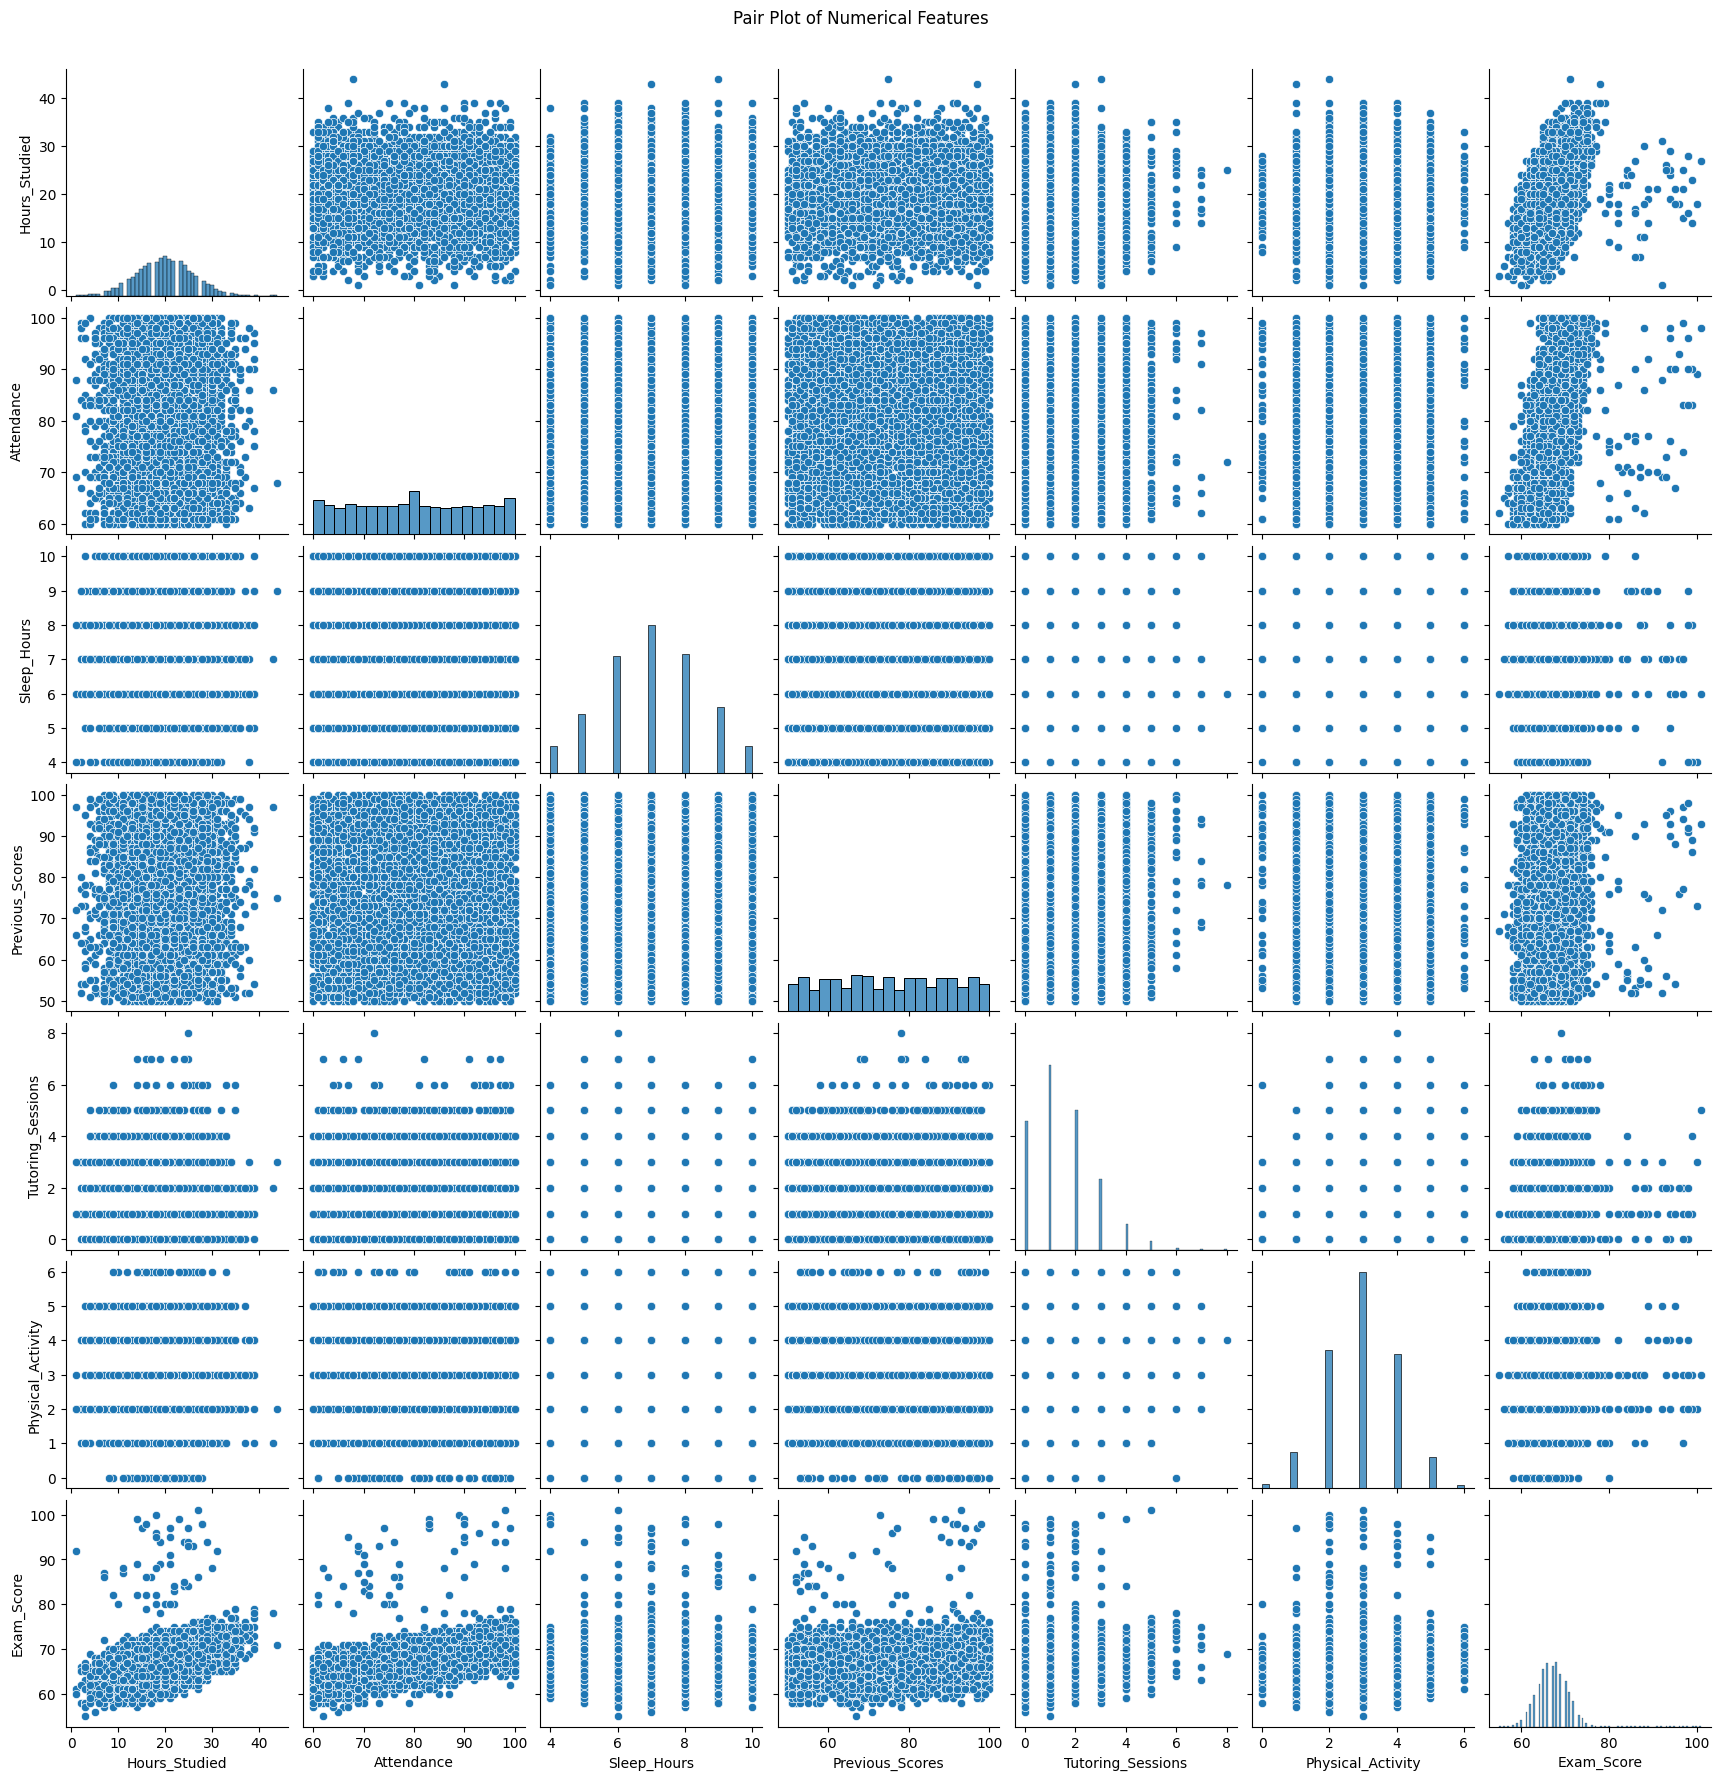

In [17]:
# Pair Plot for relationships between numerical variables

sns.pairplot(numerical_features)
plt.suptitle("Pair Plot of Numerical Features", y=1.02)
plt.show()

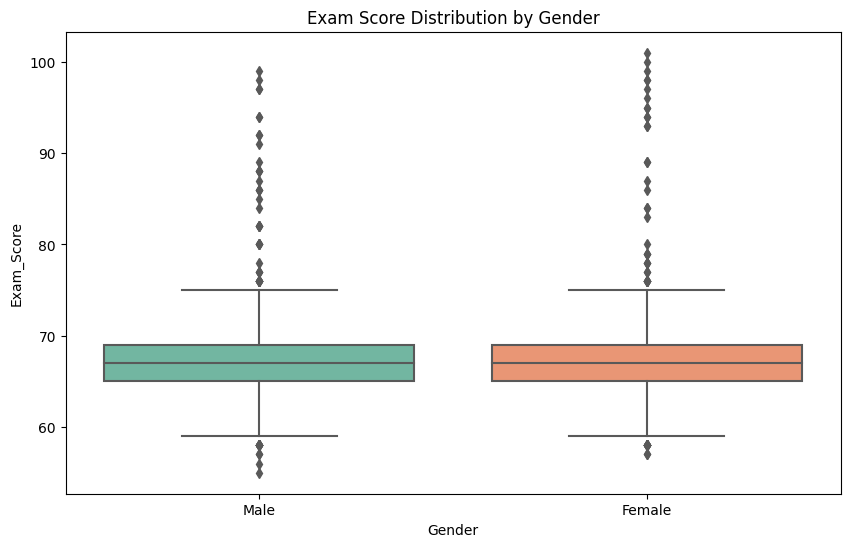

In [18]:
# Box Plot to compare Exam Score distribution across Gender

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Gender', y='Exam_Score', palette='Set2')
plt.title('Exam Score Distribution by Gender')
plt.show()

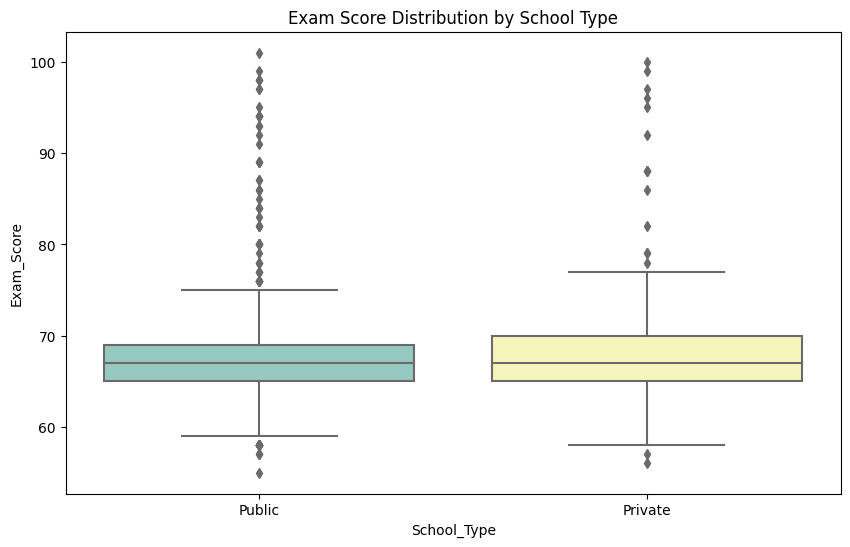

In [19]:
# Box Plot for Exam Scores Based on School Type

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='School_Type', y='Exam_Score', palette='Set3')
plt.title('Exam Score Distribution by School Type')
plt.show()

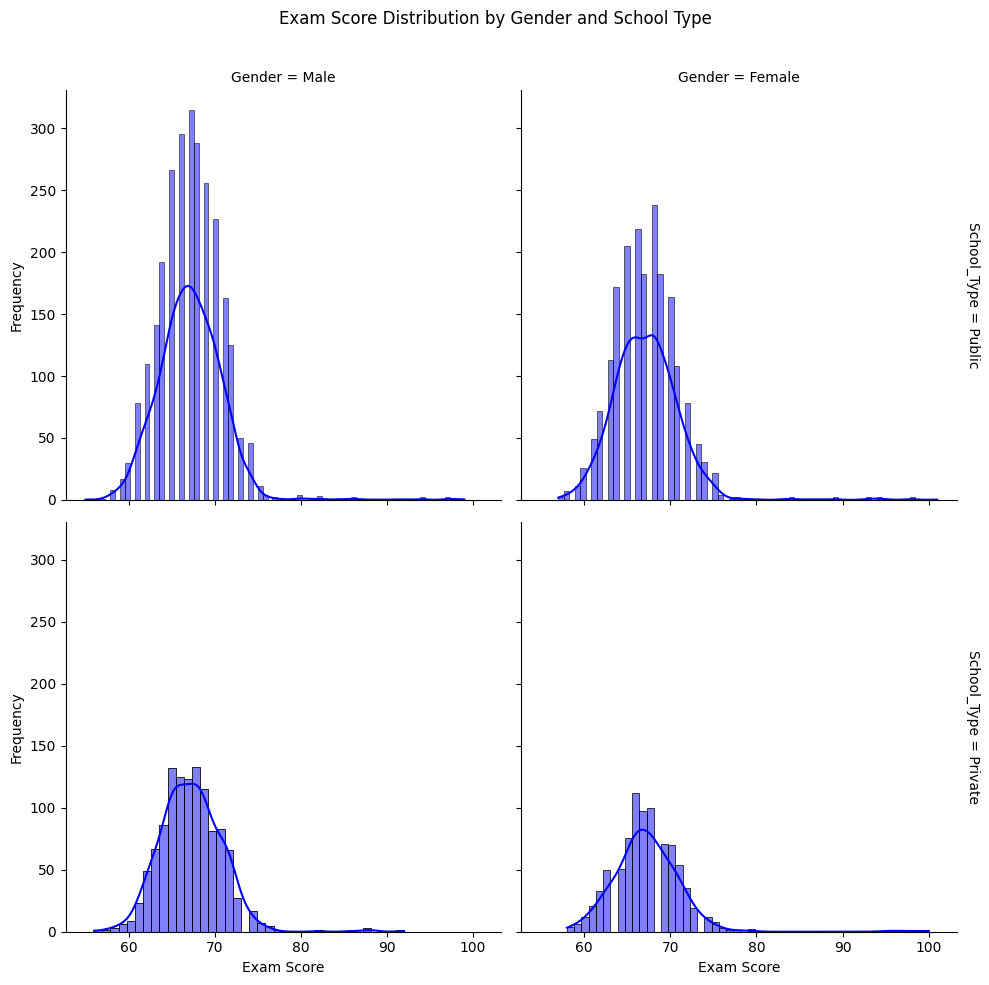

In [20]:
#  FacetGrid for Multiple Categorical Variables

g = sns.FacetGrid(df, col="Gender", row="School_Type", margin_titles=True, height=5)
g.map(sns.histplot, "Exam_Score", kde=True, color="blue")
g.set_axis_labels('Exam Score', 'Frequency')
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Exam Score Distribution by Gender and School Type')
plt.show()


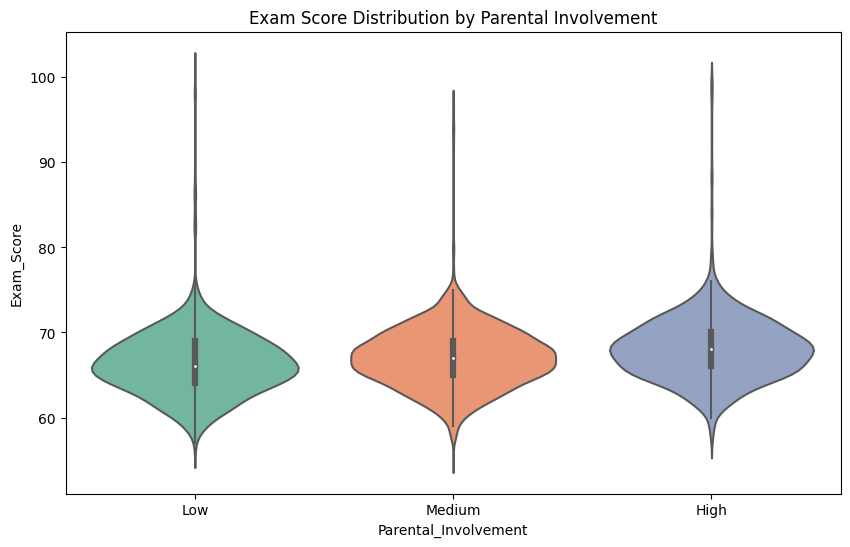

In [21]:
#  Violin Plot to Show Distribution of Exam Scores by Parental_Involvement

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Parental_Involvement', y='Exam_Score', palette='Set2')
plt.title('Exam Score Distribution by Parental Involvement')
plt.show()

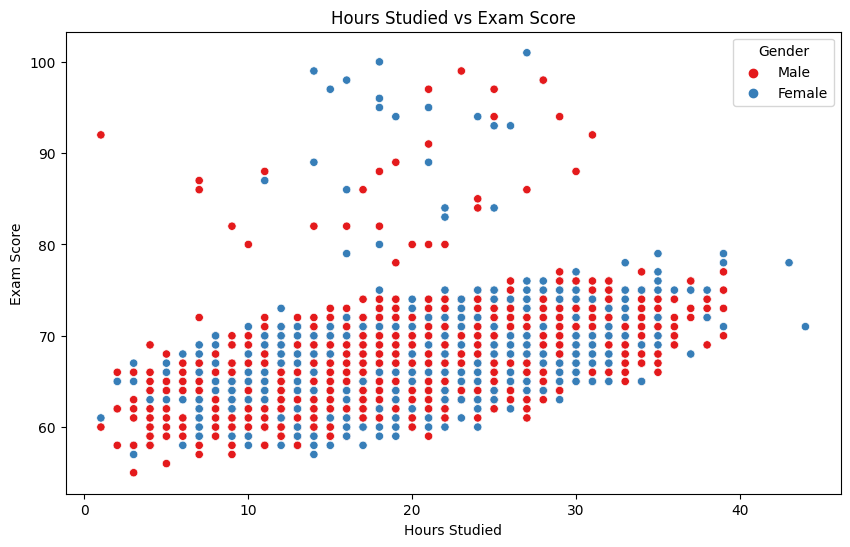

In [22]:
# Scatter Plot for Hours Studied vs Exam Score

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Hours_Studied', y='Exam_Score', hue='Gender', palette='Set1')
plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.show()

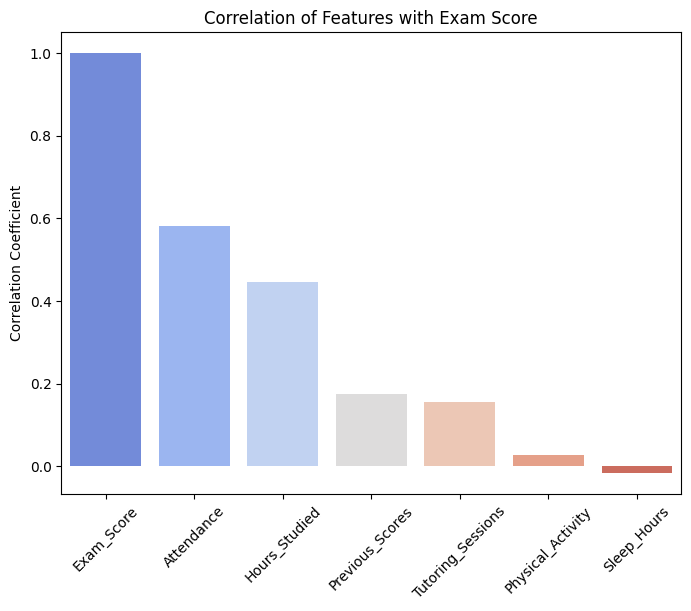

In [23]:
# correlation with Exam_Score

correlation_with_target = numerical_features.corr()['Exam_Score'].sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=correlation_with_target.index, y=correlation_with_target.values, palette='coolwarm')
plt.title('Correlation of Features with Exam Score')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45)
plt.show()

## Data Preprocessing

In [24]:
# Handling Missing Values

categorical_columns_with_missing = ['Parental_Education_Level', 'Distance_from_Home', 'Teacher_Quality']

for column in categorical_columns_with_missing:
    mode_value = df[column].mode()[0]  
    df[column].fillna(mode_value, inplace=True)
df.sample(5)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
3012,12,95,Medium,High,Yes,5,85,Medium,Yes,2,High,Medium,Public,Negative,2,No,College,Near,Male,70
5994,25,93,Medium,Medium,No,5,62,Medium,Yes,0,Low,Medium,Public,Neutral,3,No,High School,Far,Male,68
4400,23,72,Medium,Medium,Yes,8,64,Low,Yes,1,Low,Medium,Public,Neutral,4,No,Postgraduate,Near,Female,66
5173,14,82,Medium,Medium,Yes,4,67,Medium,Yes,1,High,Medium,Public,Neutral,4,No,High School,Moderate,Female,65
6562,19,91,Medium,Low,No,6,58,High,Yes,2,Low,High,Public,Positive,3,No,College,Moderate,Male,68


In [25]:
# Applying OHE to convert categoical data into numerical data 

categorical_columns = [
    'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 
    'Motivation_Level', 'Internet_Access', 'Family_Income','Teacher_Quality', 'School_Type', 
    'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level','Distance_from_Home','Gender'
]

df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)
df.sample(5)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
904,21,98,6,88,1,3,71,True,False,False,...,False,True,True,False,False,False,True,False,True,True
587,15,89,9,82,1,3,66,True,False,False,...,True,True,True,False,False,False,False,False,True,True
1134,19,63,7,58,2,3,64,True,False,False,...,False,False,True,False,False,False,True,False,True,False
4408,23,87,6,59,4,2,70,False,False,True,...,False,True,True,False,False,True,False,False,True,True
2484,17,96,7,50,1,4,67,False,True,False,...,True,False,False,False,False,True,False,False,True,False


In [26]:
# Removing outliers from dataset based on the Z-score method

z = np.abs((df - df.mean()) / df.std())
threshold = 3
df= df[(z < threshold).all(axis=1)]

## Train Test And Split

In [27]:
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [30]:
lf = LinearRegression()

lf.fit(X_train, y_train)

LinearRegression()

## Model Evaluation

In [31]:
lf_pred = lf.predict(X_test)
lf_r2 = r2_score(y_test, lf_pred)

print(f"R2 Score = {lf_r2}")

R2 Score = 0.9894221634929541


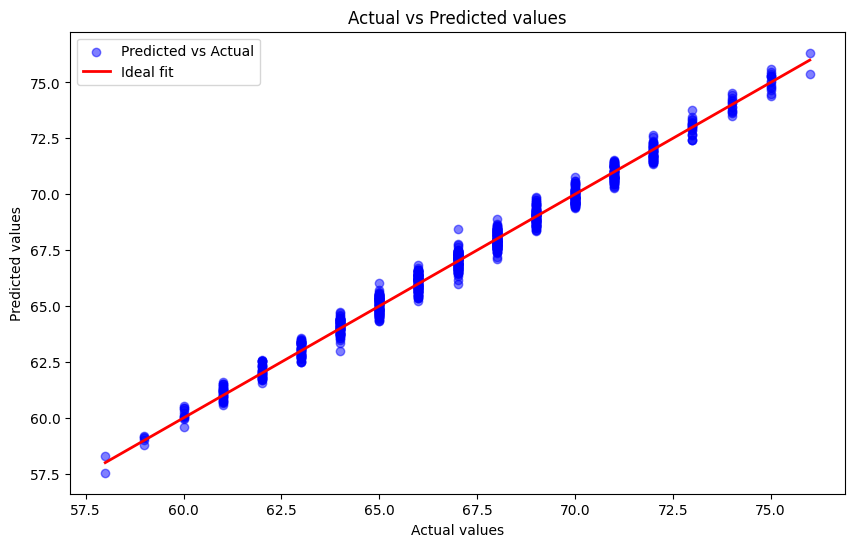

In [32]:
# Plot for Actual vs Predicted values

plt.figure(figsize=(10, 6))
plt.scatter(y_test, lf_pred, color='blue', alpha=0.5, label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2, label='Ideal fit')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Actual vs Predicted values')
plt.legend()
plt.show()

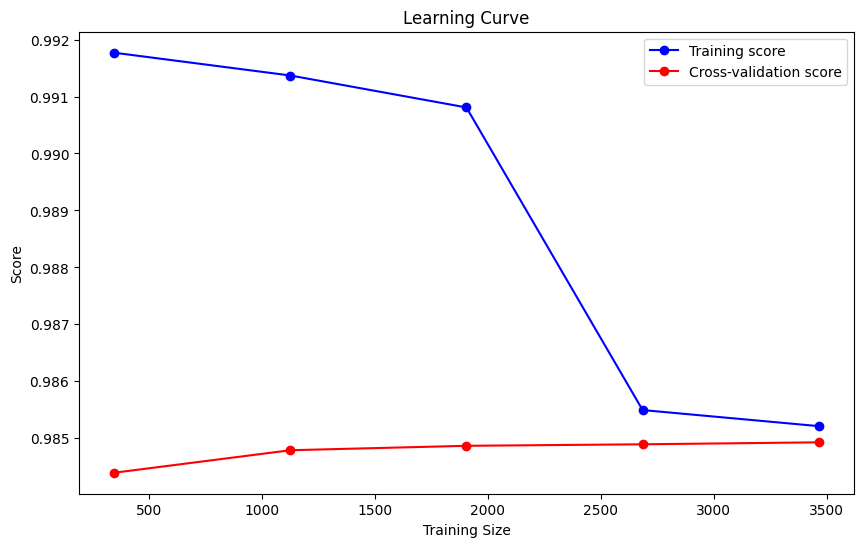

In [33]:
# Plot for learning curve

from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(lf, X_train, y_train, cv=5)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training score', color='blue', marker='o')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Cross-validation score', color='red', marker='o')
plt.xlabel('Training Size')
plt.ylabel('Score')
plt.title('Learning Curve')
plt.legend()
plt.show()

In [34]:
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': lf_pred})
print(comparison_df.head(10))

      Actual  Predicted
353       64  63.697923
2111      60  59.962330
5169      63  63.022636
2282      68  67.367322
1306      67  66.774153
3705      64  63.912229
6555      67  66.826496
359       63  63.058994
2321      67  67.223449
1877      66  66.577728


## Conclusion

In this notebook, we successfully built a model to predict student performance based on various factors, such as study time, attendance, and academic history. After thorough data preprocessing and model training, the model achieved an impressive ****R² score of approximately 99%****, indicating that it explains nearly all the variance in the dataset. 

This high performance suggests that the model is highly effective in predicting student outcomes, providing valuable insights for educators and institutions to improve academic strategies and support at-risk students. Further improvements can be made by exploring additional features or more complex models for even better predictions.

If you liked this notebook, please consider giving an upvote and following for more updates and projects!